In [50]:
import numpy as np 
import matplotlib.pyplot as plt 
import h5py
from astropy import units as u 
import agama
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{txfonts}",
})

In [2]:
def peak_frequency(signal, dt, detrend=True):
    s = signal - signal.mean() if detrend else signal
    n = len(s)
    spec = np.fft.rfft(s)
    freq = np.fft.rfftfreq(n, d=dt)          # cycles per unit time 
    power = np.abs(spec)**2

    # ignore the f=0 bin
    idx = np.argmax(power[1:]) + 1
    return freq[idx], freq, power

In [42]:
path = "/Users/ferrone/repos/bar-dynamics/simulations/"
fname = "pal5_bar_pattern_speed_v1__mw-fiducial_v1__lookback-4gyr__n-512__seed-0042__75958ac3.h5"
myfile = h5py.File(path+fname,mode="r")
mykeys = list(myfile['runs'].keys())
# pick a key 
key_index = 4
barpatternspeed=myfile['runs'][mykeys[key_index]].attrs['bar_pattern_speed_magnitude_kms_kpc']
print(barpatternspeed)

26.5


In [43]:
# extract the data
x=myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][:,0]
y=myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][:,1]
z=myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][:,2]
R = np.sqrt(x**2 + y**2)
theta = np.arctan2(y,x)
nt = len(R)
# convert gyr to integration units 
t0=-myfile.attrs['lookback_gyr']*u.Gyr
unitT=u.s * (u.kpc/u.km)
timestamps=np.linspace(0,t0.to(unitT).value,nt)

In [44]:
# do the frequency analysis of the orbit 
dt = timestamps[1] - timestamps[0]

theta_unwrapped = np.unwrap(theta)

fR, freqR, powR       = peak_frequency(R, dt)
ftheta, freqT, powT   = peak_frequency(theta_unwrapped, dt)
fz, freqZ, powZ       = peak_frequency(z, dt)

print("R peak freq:", fR,)
print("theta peak freq:", ftheta, )
print("z peak freq:", fz,)

R peak freq: -4.382877243666819
theta peak freq: -0.24349318020371216
z peak freq: -2.921918162444546


In [47]:
spectrum = (barpatternspeed - ftheta)/fR
spectrum

np.float64(-6.101812050257076)

[None, Text(0.5, 1.0, 'omega=26.50')]

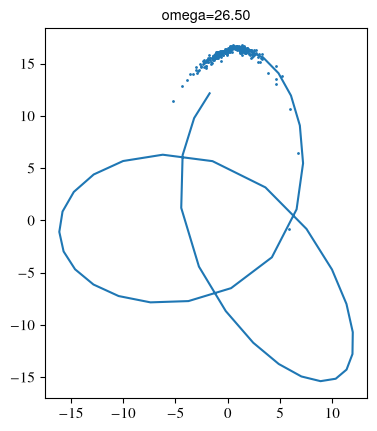

In [49]:
xp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,1]
yp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,2]
fig,axis=plt.subplots(1,1)
ll=40
axis.plot(y[-ll:],z[-ll:]);
axis.scatter(xp,yp,s=1)
axis.set(aspect="equal", title="omega={:.2f}".format(barpatternspeed))

In [35]:
dt = timestamps[1] - timestamps[0]

theta_unwrapped = np.unwrap(theta)

fR, freqR, powR       = peak_frequency(R, dt)
ftheta, freqT, powT   = peak_frequency(theta_unwrapped, dt)
fz, freqZ, powZ       = peak_frequency(z, dt)

print("R peak freq:", fR, "-> period:", 1/fR, "km/kpc/s")
print("theta peak freq:", ftheta, "-> period:", 1/ftheta, "km/kpc/s")
print("z peak freq:", fz, "-> period:", 1/fz, "km/kpc/s")

R peak freq: -4.382877243666819 -> period: -0.2281606224415668 km/kpc/s
theta peak freq: -0.24349318020371216 -> period: -4.106891203948202 km/kpc/s
z peak freq: -2.921918162444546 -> period: -0.3422409336623502 km/kpc/s


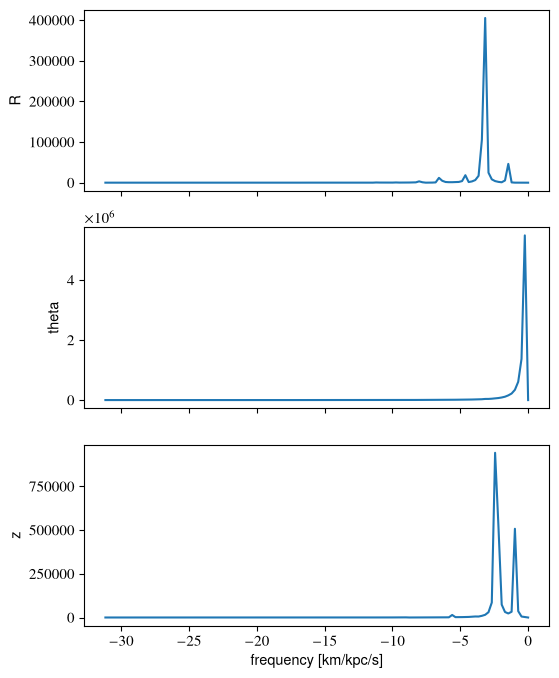

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
for ax, freq, pow_, label in zip(axes, [freqR, freqT, freqZ], [powR, powT, powZ], ["R", "theta", "z"]):
    ax.plot(freq, pow_)
    ax.set_ylabel(label)
axes[-1].set_xlabel("frequency [km/kpc/s]");

In [ ]:
# try to compute the actions with Agama
import sys 
sys.path.append("../experiments/")
import bar_pattern_speed_sweep as bpss #ignore 

In [ ]:
configpath = "../parameters/mwmodelbar_pattern_speed.ini"
config = bpss.configparsers.ConfigParser()
bpss.make_potential(configpath)

AttributeError: 'str' object has no attribute 'get'